Excluded 3 non-feature columns: ['window_index', 'label_original', 'stress_label']
Comparing 0 feature columns:
[]

 No feature columns to compare. Diagnostics:
Numeric columns in BEFORE file: ['window_index', 'label_original', 'stress_label', 'ACC_x_mean', 'ACC_x_median', 'ACC_x_std', 'ACC_x_variance', 'ACC_x_min', 'ACC_x_max', 'ACC_x_range', 'ACC_x_iqr', 'ACC_x_skewness', 'ACC_x_kurtosis', 'ACC_x_rms', 'ACC_x_energy', 'ACC_x_entropy', 'ACC_x_mav', 'ACC_x_auc', 'ACC_x_slope', 'ACC_x_zero_crossing_rate', 'ACC_x_cv', 'ACC_y_mean', 'ACC_y_median', 'ACC_y_std', 'ACC_y_variance', 'ACC_y_min', 'ACC_y_max', 'ACC_y_range', 'ACC_y_iqr', 'ACC_y_skewness', 'ACC_y_kurtosis', 'ACC_y_rms', 'ACC_y_energy', 'ACC_y_entropy', 'ACC_y_mav', 'ACC_y_auc', 'ACC_y_slope', 'ACC_y_zero_crossing_rate', 'ACC_y_cv', 'ACC_z_mean', 'ACC_z_median', 'ACC_z_std', 'ACC_z_variance', 'ACC_z_min', 'ACC_z_max', 'ACC_z_range', 'ACC_z_iqr', 'ACC_z_skewness', 'ACC_z_kurtosis', 'ACC_z_rms', 'ACC_z_energy', 'ACC_z_entropy', 'AC

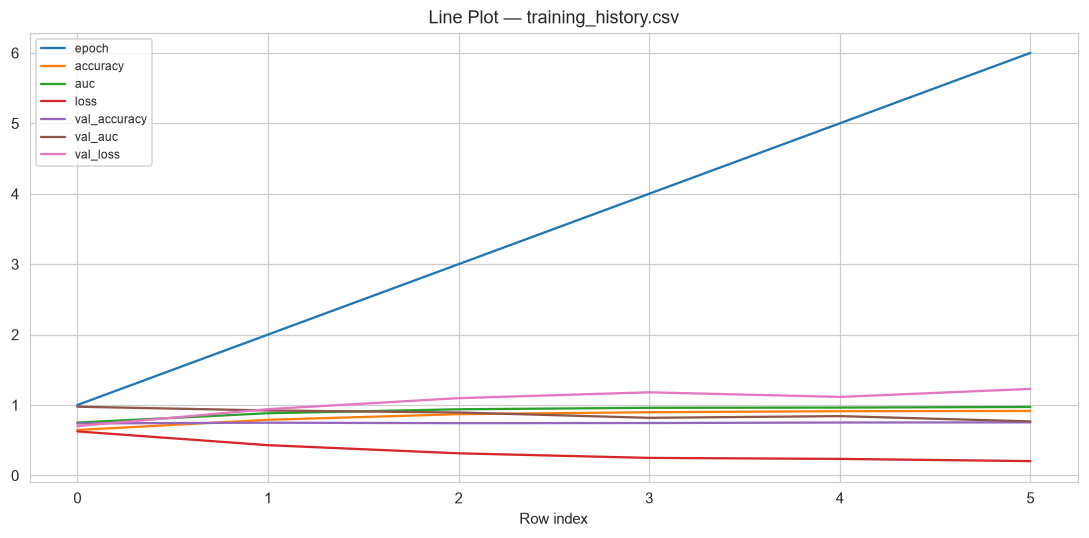


Loaded: metrics.csv
Shape: (1, 7)
  variant test_subjects  test_accuracy  test_auc  n_features  n_train  n_test
0     raw            S2       0.738516  0.976601         108     1728     849


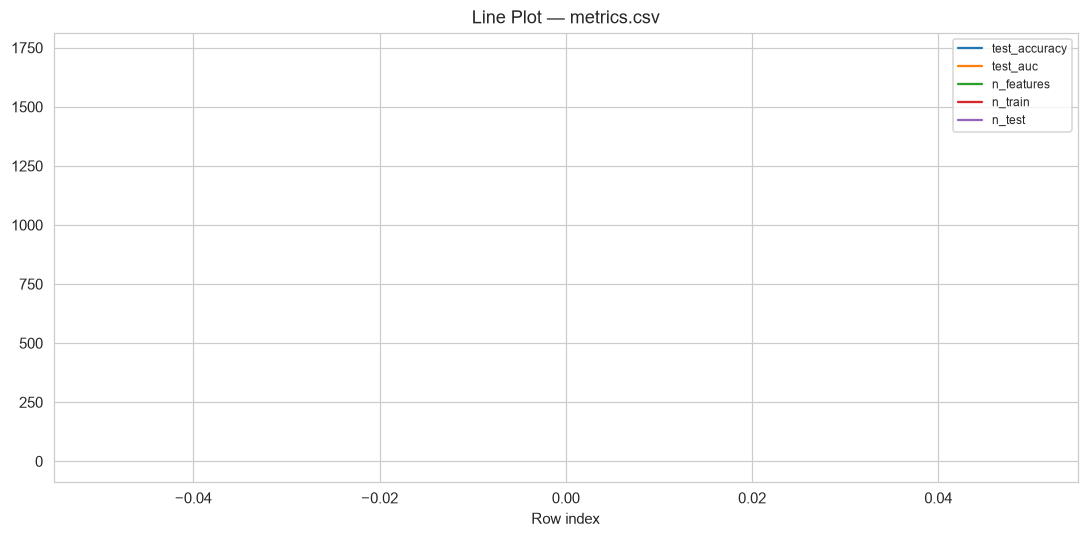

In [5]:
"""
UNIVERSAL CSV PLOTTER
======================
Just change the file path(s) at the bottom (in the `if __name__ == "__main__":`
block) and run this script. Works on ANY csv in your project
(features_before_model.csv, features_after_model.csv, metrics.csv,
training_history.csv, model_comparison.csv, classification_report.csv, etc.)

Usage examples are at the very bottom of this file.

Requires: pandas, matplotlib, seaborn, numpy  (all already installed)
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


# ----------------------------------------------------------------------
# 1) GENERIC "PLOT ANYTHING" FUNCTION
# ----------------------------------------------------------------------
def plot_csv(
    filepath,
    columns=None,
    kind="auto",
    max_cols=12,
    sample_rows=None,
    save_path=None,
):
    """
    Auto-plots a CSV file. Works for almost any tabular file:
    feature tables, training histories, metrics, model comparisons, etc.

    Parameters
    ----------
    filepath : str
        Path to the .csv file.
    columns : list[str] or None
        Specific numeric columns to plot. If None, auto-detects all
        numeric columns (up to `max_cols`).
    kind : str
        "auto"  -> picks line plot for time/step-like data, histogram
                   for feature/distribution-like data
        "line"  -> force line plot (good for training_history.csv, metrics.csv)
        "hist"  -> force histograms (good for feature distributions)
        "box"   -> boxplots (good for comparing feature scales/outliers)
        "bar"   -> bar chart (good for classification_report.csv style tables)
        "heatmap" -> correlation heatmap of numeric columns
    max_cols : int
        Cap on number of columns plotted (keeps things readable).
    sample_rows : int or None
        If the file is huge, randomly sample this many rows before plotting.
    save_path : str or None
        If given, saves the figure to this path instead of just showing it.
    """
    df = pd.read_csv(filepath)
    print(f"\nLoaded: {filepath}")
    print(f"Shape: {df.shape}")
    print(df.head())

    if sample_rows and len(df) > sample_rows:
        df = df.sample(sample_rows, random_state=42)

    numeric_df = df.select_dtypes(include=[np.number])
    if columns:
        numeric_df = numeric_df[columns]
    numeric_df = numeric_df.iloc[:, :max_cols]

    if numeric_df.empty:
        print("No numeric columns found — printing raw table instead.")
        print(df)
        return

    n = numeric_df.shape[1]
    fname = os.path.basename(filepath)

    # ---- auto-decide plot kind ----
    if kind == "auto":
        col_names_lower = " ".join(numeric_df.columns).lower()
        if any(k in col_names_lower for k in ["epoch", "step", "loss", "accuracy", "time"]):
            kind = "line"
        elif n > 6:
            kind = "hist"
        else:
            kind = "box"

    # ---- HEATMAP ----
    if kind == "heatmap":
        plt.figure(figsize=(0.6 * n + 3, 0.6 * n + 3))
        sns.heatmap(numeric_df.corr(), annot=n <= 20, cmap="coolwarm", center=0, fmt=".2f")
        plt.title(f"Correlation Heatmap — {fname}")
        plt.tight_layout()

    # ---- LINE (time series / training curves) ----
    elif kind == "line":
        fig, ax = plt.subplots(figsize=(10, 5))
        for col in numeric_df.columns:
            ax.plot(numeric_df[col].values, label=col, linewidth=1.5)
        ax.set_title(f"Line Plot — {fname}")
        ax.set_xlabel("Row index")
        ax.legend(loc="best", fontsize=8)
        plt.tight_layout()

    # ---- HISTOGRAMS (distributions per feature) ----
    elif kind == "hist":
        ncols = min(4, n)
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
        axes = np.array(axes).reshape(-1)
        for i, col in enumerate(numeric_df.columns):
            axes[i].hist(numeric_df[col].dropna(), bins=30, color="steelblue", edgecolor="white")
            axes[i].set_title(col, fontsize=9)
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
        fig.suptitle(f"Feature Distributions — {fname}", y=1.02)
        plt.tight_layout()

    # ---- BOXPLOT (compare scales / spot outliers) ----
    elif kind == "box":
        plt.figure(figsize=(max(6, n * 1.2), 5))
        sns.boxplot(data=numeric_df, orient="v")
        plt.xticks(rotation=45, ha="right")
        plt.title(f"Boxplot — {fname}")
        plt.tight_layout()

    # ---- BAR (for report-style csvs, e.g. classification_report.csv) ----
    elif kind == "bar":
        plt.figure(figsize=(max(6, n * 1.5), 5))
        numeric_df.plot(kind="bar", ax=plt.gca())
        plt.title(f"Bar Chart — {fname}")
        plt.tight_layout()

    else:
        raise ValueError(f"Unknown kind: {kind}")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Saved to {save_path}")
    plt.show()


# ----------------------------------------------------------------------
# 2) BEFORE vs AFTER COMPARISON — SAME SCALE
# ----------------------------------------------------------------------
DEFAULT_EXCLUDE_COLS = [
    "index", "window_index", "row_index", "id", "subject", "subject_id",
    "participant", "participant_id", "label", "label_original", "target",
    "stress_label", "class", "y", "timestamp", "time", "unnamed: 0",
]


def compare_before_after(
    before_path,
    after_path,
    columns=None,
    max_cols=16,
    exclude_cols=DEFAULT_EXCLUDE_COLS,
    save_path=None,
):
    """
    Plots features_before_model.csv vs features_after_model.csv (or any
    two comparable CSVs) side-by-side on a *shared* y-axis scale, so you
    can see how the values shifted (e.g. before vs after scaling/normalization).

    Produces:
      1) One boxplot per feature, before vs after, same y-axis -> shows
         scale/spread change at a glance.
      2) An overlaid distribution (KDE) plot per feature.
    """
    df_before = pd.read_csv(before_path)
    df_after = pd.read_csv(after_path)

    num_before = df_before.select_dtypes(include=[np.number])
    num_after = df_after.select_dtypes(include=[np.number])

    if columns is None:
        shared = [c for c in num_before.columns if c in num_after.columns]
        exclude_lower = {e.lower() for e in (exclude_cols or [])}
        kept = [c for c in shared if c.lower() not in exclude_lower]
        dropped = [c for c in shared if c.lower() in exclude_lower]
        columns = kept[:max_cols]
        if dropped:
            print(f"Excluded {len(dropped)} non-feature columns: {dropped}")
        if len(kept) > max_cols:
            print(f"Note: {len(kept)} feature columns available, only plotting first {max_cols}. "
                  f"Pass columns=[...] to choose specific ones, or raise max_cols.")

    print(f"Comparing {len(columns)} feature columns:")
    print(columns)

    if len(columns) == 0:
        print("\n No feature columns to compare. Diagnostics:")
        print("Numeric columns in BEFORE file:", num_before.columns.tolist())
        print("Numeric columns in AFTER file: ", num_after.columns.tolist())
        print("\nThis usually means the column names differ between the two files")
        print("(e.g. 'heart_rate' vs 'heart_rate_scaled'), or the after-file's")
        print("feature columns aren't numeric (check dtypes with df.dtypes).")
        print("Fix: pass columns=[...] explicitly, e.g.:")
        print('  compare_before_after(before_path, after_path,')
        print('      columns=["heart_rate", "eda_mean"])  # use real before-file names')
        print('  # or if names differ, plot each file separately with plot_csv() instead.')
        return

    # Global shared scale across BOTH datasets and all selected columns
    all_vals = pd.concat([num_before[columns], num_after[columns]]).values.flatten()
    all_vals = all_vals[~np.isnan(all_vals)]
    ymin, ymax = np.percentile(all_vals, [0.5, 99.5])  # robust to outliers
    pad = (ymax - ymin) * 0.05
    ymin, ymax = ymin - pad, ymax + pad

    n = len(columns)
    ncols = min(4, n)
    nrows = int(np.ceil(n / ncols))

    # ---- Plot 1: side-by-side boxplots on shared y-scale ----
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(columns):
        data = [df_before[col].dropna(), df_after[col].dropna()]
        try:
            # matplotlib >= 3.9
            axes[i].boxplot(data, tick_labels=["Before", "After"], patch_artist=True,
                             boxprops=dict(facecolor="lightsteelblue"))
        except TypeError:
            # matplotlib < 3.9
            axes[i].boxplot(data, labels=["Before", "After"], patch_artist=True,
                             boxprops=dict(facecolor="lightsteelblue"))
        axes[i].set_ylim(ymin, ymax)
        axes[i].set_title(col, fontsize=9)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle("Feature Scale: Before vs After Model Processing (shared y-axis)", y=1.02)
    plt.tight_layout()
    if save_path:
        base, ext = os.path.splitext(save_path)
        plt.savefig(f"{base}_boxplot{ext}", bbox_inches="tight")
    plt.show()

    # ---- Plot 2: overlaid KDE distributions on shared x-scale ----
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(columns):
        sns.kdeplot(df_before[col].dropna(), ax=axes[i], label="Before", fill=True, alpha=0.4)
        sns.kdeplot(df_after[col].dropna(), ax=axes[i], label="After", fill=True, alpha=0.4)
        axes[i].set_xlim(ymin, ymax)
        axes[i].set_title(col, fontsize=9)
        axes[i].legend(fontsize=7)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle("Feature Distributions: Before vs After (shared x-axis)", y=1.02)
    plt.tight_layout()
    if save_path:
        base, ext = os.path.splitext(save_path)
        plt.savefig(f"{base}_kde{ext}", bbox_inches="tight")
    plt.show()


# ----------------------------------------------------------------------
# 3) RUN IT — just edit the paths/kinds below
# ----------------------------------------------------------------------
if __name__ == "__main__":

    # --- A) Compare features_before_model.csv vs features_after_model.csv ---
    compare_before_after(
        before_path="features_before_model.csv",
        after_path="features_after_model.csv",
        # columns=["feature1", "feature2"],   # optional: restrict to specific columns
        save_path="before_after_comparison.png",  # optional
    )

    # --- B) Plot literally any other CSV, just change the filename & kind ---
    # training_history.csv -> line plot of loss/accuracy over epochs
    plot_csv("training_history.csv", kind="line")

    # metrics.csv -> auto-detects best plot type
    plot_csv("metrics.csv", kind="auto")

    #  
    # -----------------------------------------------------------------
    # GENERAL RULE: for ANY new csv, just call:
    #   plot_csv("path/to/file.csv")                 # auto mode, or
    #   plot_csv("path/to/file.csv", kind="line")     # force a specific kind
    # kind options: "auto", "line", "hist", "box", "bar", "heatmap"
    # -----------------------------------------------------------------

In [ ]:
"""
UNIVERSAL CSV PLOTTER
======================
Just change the file path(s) at the bottom (in the `if __name__ == "__main__":`
block) and run this script. Works on ANY csv in your project
(features_before_model.csv, features_after_model.csv, metrics.csv,
training_history.csv, model_comparison.csv, classification_report.csv, etc.)

Usage examples are at the very bottom of this file.

Requires: pandas, matplotlib, seaborn, numpy  (all already installed)
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


# ----------------------------------------------------------------------
# 1) GENERIC "PLOT ANYTHING" FUNCTION
# ----------------------------------------------------------------------
def plot_csv(
    filepath,
    columns=None,
    kind="auto",
    max_cols=12,
    sample_rows=None,
    save_path=None,
):
    """
    Auto-plots a CSV file. Works for almost any tabular file:
    feature tables, training histories, metrics, model comparisons, etc.

    Parameters
    ----------
    filepath : str
        Path to the .csv file.
    columns : list[str] or None
        Specific numeric columns to plot. If None, auto-detects all
        numeric columns (up to `max_cols`).
    kind : str
        "auto"  -> picks line plot for time/step-like data, histogram
                   for feature/distribution-like data
        "line"  -> force line plot (good for training_history.csv, metrics.csv)
        "hist"  -> force histograms (good for feature distributions)
        "box"   -> boxplots (good for comparing feature scales/outliers)
        "bar"   -> bar chart (good for classification_report.csv style tables)
        "heatmap" -> correlation heatmap of numeric columns
    max_cols : int
        Cap on number of columns plotted (keeps things readable).
    sample_rows : int or None
        If the file is huge, randomly sample this many rows before plotting.
    save_path : str or None
        If given, saves the figure to this path instead of just showing it.
    """
    df = pd.read_csv(filepath)
    print(f"\nLoaded: {filepath}")
    print(f"Shape: {df.shape}")
    print(df.head())

    if sample_rows and len(df) > sample_rows:
        df = df.sample(sample_rows, random_state=42)

    numeric_df = df.select_dtypes(include=[np.number])
    if columns:
        numeric_df = numeric_df[columns]
    numeric_df = numeric_df.iloc[:, :max_cols]

    if numeric_df.empty:
        print("No numeric columns found — printing raw table instead.")
        print(df)
        return

    n = numeric_df.shape[1]
    fname = os.path.basename(filepath)

    # ---- auto-decide plot kind ----
    if kind == "auto":
        col_names_lower = " ".join(numeric_df.columns).lower()
        if any(k in col_names_lower for k in ["epoch", "step", "loss", "accuracy", "time"]):
            kind = "line"
        elif n > 6:
            kind = "hist"
        else:
            kind = "box"

    # ---- HEATMAP ----
    if kind == "heatmap":
        plt.figure(figsize=(0.6 * n + 3, 0.6 * n + 3))
        sns.heatmap(numeric_df.corr(), annot=n <= 20, cmap="coolwarm", center=0, fmt=".2f")
        plt.title(f"Correlation Heatmap — {fname}")
        plt.tight_layout()

    # ---- LINE (time series / training curves) ----
    elif kind == "line":
        fig, ax = plt.subplots(figsize=(10, 5))
        for col in numeric_df.columns:
            ax.plot(numeric_df[col].values, label=col, linewidth=1.5)
        ax.set_title(f"Line Plot — {fname}")
        ax.set_xlabel("Row index")
        ax.legend(loc="best", fontsize=8)
        plt.tight_layout()

    # ---- HISTOGRAMS (distributions per feature) ----
    elif kind == "hist":
        ncols = min(4, n)
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
        axes = np.array(axes).reshape(-1)
        for i, col in enumerate(numeric_df.columns):
            axes[i].hist(numeric_df[col].dropna(), bins=30, color="steelblue", edgecolor="white")
            axes[i].set_title(col, fontsize=9)
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
        fig.suptitle(f"Feature Distributions — {fname}", y=1.02)
        plt.tight_layout()

    # ---- BOXPLOT (compare scales / spot outliers) ----
    elif kind == "box":
        plt.figure(figsize=(max(6, n * 1.2), 5))
        sns.boxplot(data=numeric_df, orient="v")
        plt.xticks(rotation=45, ha="right")
        plt.title(f"Boxplot — {fname}")
        plt.tight_layout()

    # ---- BAR (for report-style csvs, e.g. classification_report.csv) ----
    elif kind == "bar":
        plt.figure(figsize=(max(6, n * 1.5), 5))
        numeric_df.plot(kind="bar", ax=plt.gca())
        plt.title(f"Bar Chart — {fname}")
        plt.tight_layout()

    else:
        raise ValueError(f"Unknown kind: {kind}")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Saved to {save_path}")
    plt.show()


# ----------------------------------------------------------------------
# 2) BEFORE vs AFTER COMPARISON — SAME SCALE
# ----------------------------------------------------------------------
DEFAULT_EXCLUDE_COLS = [
    "index", "window_index", "row_index", "id", "subject", "subject_id",
    "participant", "participant_id", "label", "label_original", "target",
    "stress_label", "class", "y", "timestamp", "time", "unnamed: 0",
]


def compare_before_after(
    before_path,
    after_path,
    columns=None,
    max_cols=16,
    exclude_cols=DEFAULT_EXCLUDE_COLS,
    save_path=None,
):
    """
    Plots features_before_model.csv vs features_after_model.csv (or any
    two comparable CSVs) side-by-side on a *shared* y-axis scale, so you
    can see how the values shifted (e.g. before vs after scaling/normalization).

    Produces:
      1) One boxplot per feature, before vs after, same y-axis -> shows
         scale/spread change at a glance.
      2) An overlaid distribution (KDE) plot per feature.
    """
    df_before = pd.read_csv(before_path)
    df_after = pd.read_csv(after_path)

    num_before = df_before.select_dtypes(include=[np.number])
    num_after = df_after.select_dtypes(include=[np.number])

    if columns is None:
        shared = [c for c in num_before.columns if c in num_after.columns]
        exclude_lower = {e.lower() for e in (exclude_cols or [])}
        kept = [c for c in shared if c.lower() not in exclude_lower]
        dropped = [c for c in shared if c.lower() in exclude_lower]
        columns = kept[:max_cols]
        if dropped:
            print(f"Excluded {len(dropped)} non-feature columns: {dropped}")
        if len(kept) > max_cols:
            print(f"Note: {len(kept)} feature columns available, only plotting first {max_cols}. "
                  f"Pass columns=[...] to choose specific ones, or raise max_cols.")

    print(f"Comparing {len(columns)} feature columns:")
    print(columns)

    # Global shared scale across BOTH datasets and all selected columns
    all_vals = pd.concat([num_before[columns], num_after[columns]]).values.flatten()
    all_vals = all_vals[~np.isnan(all_vals)]
    ymin, ymax = np.percentile(all_vals, [0.5, 99.5])  # robust to outliers
    pad = (ymax - ymin) * 0.05
    ymin, ymax = ymin - pad, ymax + pad

    n = len(columns)
    ncols = min(4, n)
    nrows = int(np.ceil(n / ncols))

    # ---- Plot 1: side-by-side boxplots on shared y-scale ----
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(columns):
        data = [df_before[col].dropna(), df_after[col].dropna()]
        try:
            # matplotlib >= 3.9
            axes[i].boxplot(data, tick_labels=["Before", "After"], patch_artist=True,
                             boxprops=dict(facecolor="lightsteelblue"))
        except TypeError:
            # matplotlib < 3.9
            axes[i].boxplot(data, labels=["Before", "After"], patch_artist=True,
                             boxprops=dict(facecolor="lightsteelblue"))
        axes[i].set_ylim(ymin, ymax)
        axes[i].set_title(col, fontsize=9)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle("Feature Scale: Before vs After Model Processing (shared y-axis)", y=1.02)
    plt.tight_layout()
    if save_path:
        base, ext = os.path.splitext(save_path)
        plt.savefig(f"{base}_boxplot{ext}", bbox_inches="tight")
    plt.show()

    # ---- Plot 2: overlaid KDE distributions on shared x-scale ----
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(columns):
        sns.kdeplot(df_before[col].dropna(), ax=axes[i], label="Before", fill=True, alpha=0.4)
        sns.kdeplot(df_after[col].dropna(), ax=axes[i], label="After", fill=True, alpha=0.4)
        axes[i].set_xlim(ymin, ymax)
        axes[i].set_title(col, fontsize=9)
        axes[i].legend(fontsize=7)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle("Feature Distributions: Before vs After (shared x-axis)", y=1.02)
    plt.tight_layout()
    if save_path:
        base, ext = os.path.splitext(save_path)
        plt.savefig(f"{base}_kde{ext}", bbox_inches="tight")
    plt.show()


# ----------------------------------------------------------------------
# 3) RUN IT — just edit the paths/kinds below
# ----------------------------------------------------------------------
if __name__ == "__main__":

    # --- A) Compare features_before_model.csv vs features_after_model.csv ---
    compare_before_after(
        before_path="features_before_model.csv",
        after_path="features_after_model.csv",
        # columns=["feature1", "feature2"],   # optional: restrict to specific columns
        save_path="before_after_comparison.png",  # optional
    )

    # --- B) Plot literally any other CSV, just change the filename & kind ---
    # training_history.csv -> line plot of loss/accuracy over epochs
    plot_csv("training_history.csv", kind="line")

    # metrics.csv -> auto-detects best plot type
    plot_csv("metrics.csv", kind="auto")
  
     
    # -----------------------------------------------------------------
    # GENERAL RULE: for ANY new csv, just call:
    #   plot_csv("path/to/file.csv")                 # auto mode, or
    #   plot_csv("path/to/file.csv", kind="line")     # force a specific kind
    # kind options: "auto", "line", "hist", "box", "bar", "heatmap"
    # -----------------------------------------------------------------

Excluded 3 non-feature columns: ['window_index', 'label_original', 'stress_label']
Comparing 0 feature columns:
[]


IndexError: index -1 is out of bounds for axis 0 with size 0

Comparing 3 shared numeric columns:
['window_index', 'label_original', 'stress_label']


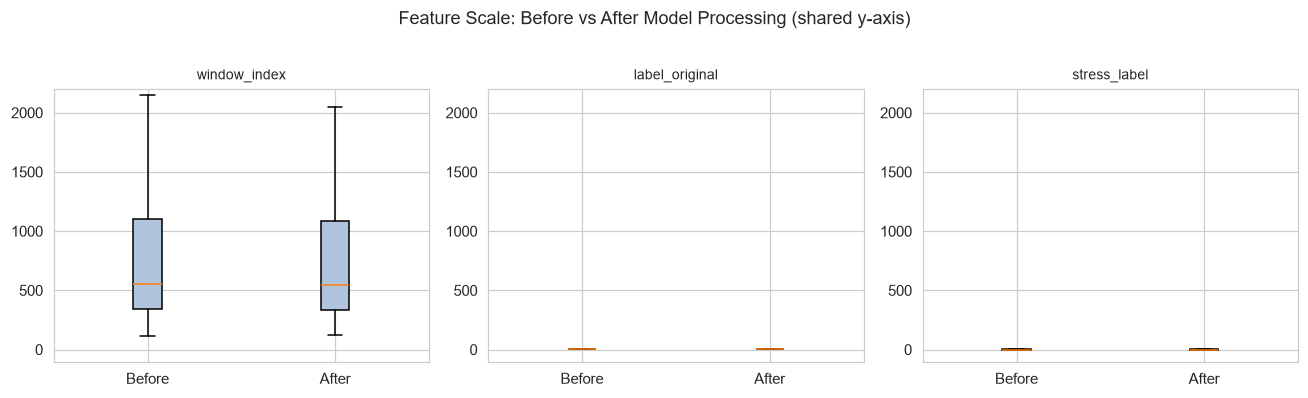

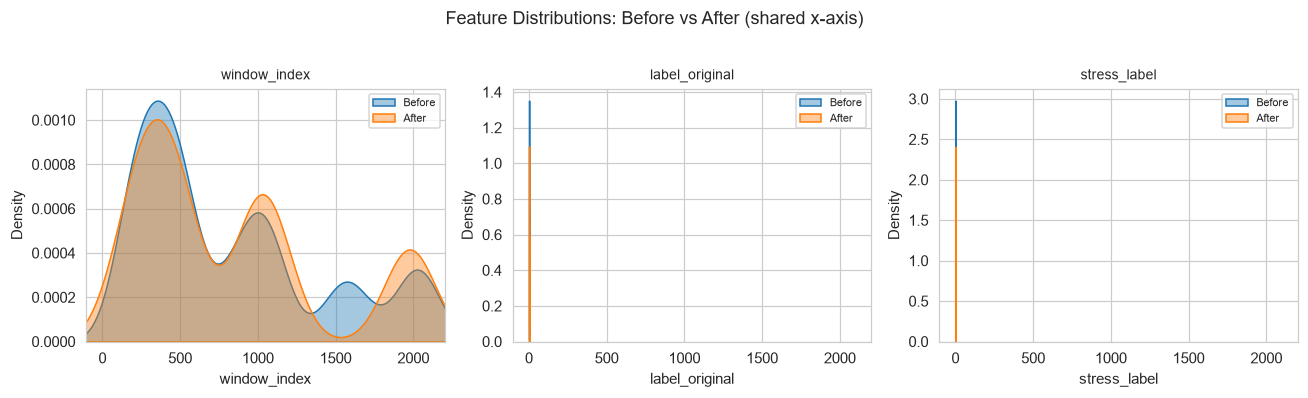


Loaded: training_history.csv
Shape: (6, 7)
   epoch  accuracy       auc      loss  val_accuracy   val_auc  val_loss
0      1  0.645255  0.750861  0.625386      0.738516  0.975977  0.700185
1      2  0.789931  0.883333  0.429723      0.749117  0.922586  0.941162
2      3  0.869792  0.939470  0.314277      0.742049  0.893685  1.097582
3      4  0.897569  0.960627  0.249154      0.744405  0.818270  1.180534
4      5  0.912037  0.963692  0.234927      0.751472  0.842397  1.115191


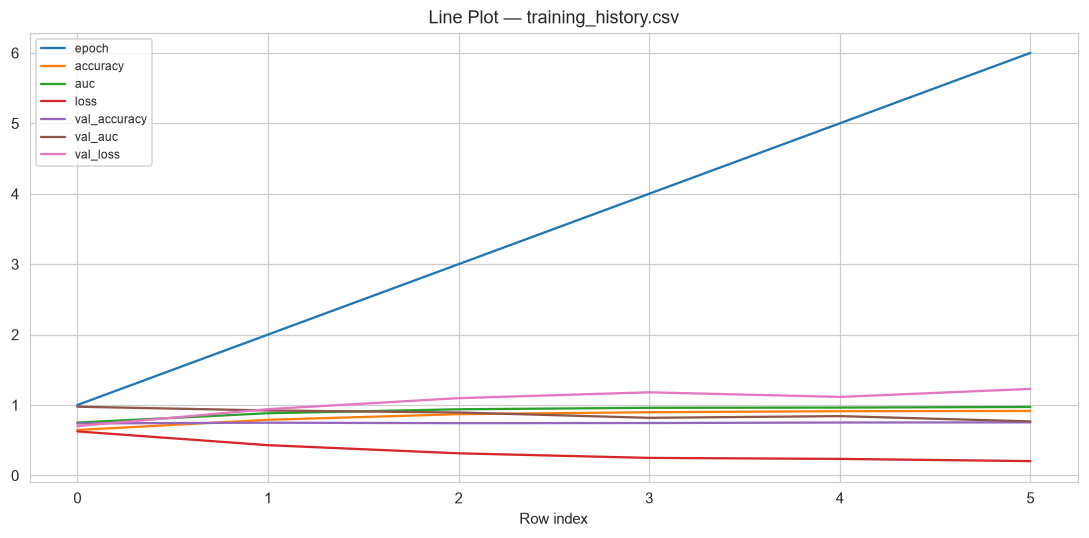


Loaded: metrics.csv
Shape: (1, 7)
  variant test_subjects  test_accuracy  test_auc  n_features  n_train  n_test
0     raw            S2       0.738516  0.976601         108     1728     849


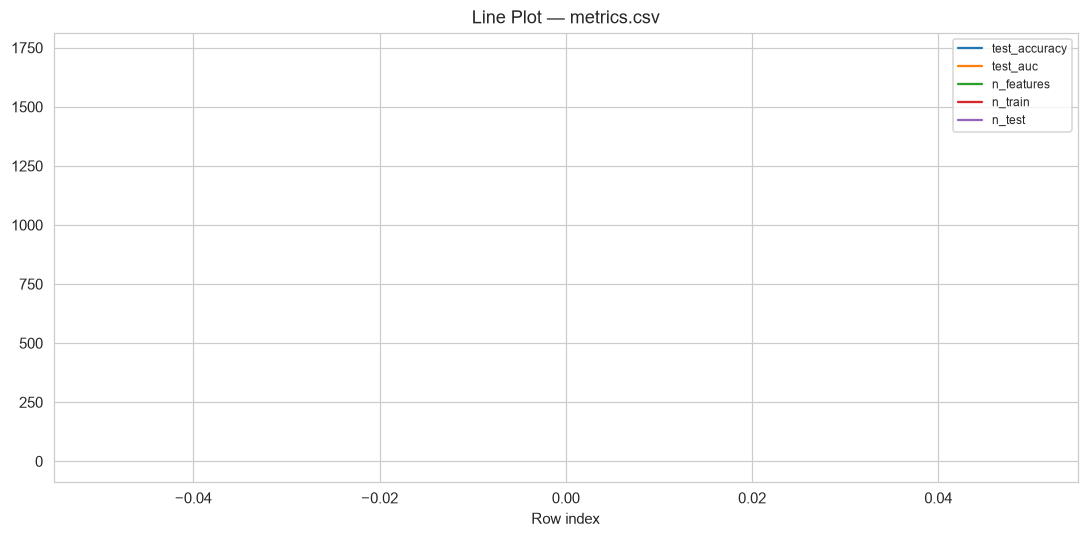

FileNotFoundError: [Errno 2] No such file or directory: '07_classical_ml/filtered/all_model_comparisons.csv'

In [ ]:
"""
UNIVERSAL CSV PLOTTER
======================
Just change the file path(s) at the bottom (in the `if __name__ == "__main__":`
block) and run this script. Works on ANY csv in your project
(features_before_model.csv, features_after_model.csv, metrics.csv,
training_history.csv, model_comparison.csv, classification_report.csv, etc.)

Usage examples are at the very bottom of this file.

Requires: pandas, matplotlib, seaborn, numpy  (all already installed)
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


# ----------------------------------------------------------------------
# 1) GENERIC "PLOT ANYTHING" FUNCTION
# ----------------------------------------------------------------------
def plot_csv(
    filepath,
    columns=None,
    kind="auto",
    max_cols=12,
    sample_rows=None,
    save_path=None,
):
    """
    Auto-plots a CSV file. Works for almost any tabular file:
    feature tables, training histories, metrics, model comparisons, etc.

    Parameters
    ----------
    filepath : str
        Path to the .csv file.
    columns : list[str] or None
        Specific numeric columns to plot. If None, auto-detects all
        numeric columns (up to `max_cols`).
    kind : str
        "auto"  -> picks line plot for time/step-like data, histogram
                   for feature/distribution-like data
        "line"  -> force line plot (good for training_history.csv, metrics.csv)
        "hist"  -> force histograms (good for feature distributions)
        "box"   -> boxplots (good for comparing feature scales/outliers)
        "bar"   -> bar chart (good for classification_report.csv style tables)
        "heatmap" -> correlation heatmap of numeric columns
    max_cols : int
        Cap on number of columns plotted (keeps things readable).
    sample_rows : int or None
        If the file is huge, randomly sample this many rows before plotting.
    save_path : str or None
        If given, saves the figure to this path instead of just showing it.
    """
    df = pd.read_csv(filepath)
    print(f"\nLoaded: {filepath}")
    print(f"Shape: {df.shape}")
    print(df.head())

    if sample_rows and len(df) > sample_rows:
        df = df.sample(sample_rows, random_state=42)

    numeric_df = df.select_dtypes(include=[np.number])
    if columns:
        numeric_df = numeric_df[columns]
    numeric_df = numeric_df.iloc[:, :max_cols]

    if numeric_df.empty:
        print("No numeric columns found — printing raw table instead.")
        print(df)
        return

    n = numeric_df.shape[1]
    fname = os.path.basename(filepath)

    # ---- auto-decide plot kind ----
    if kind == "auto":
        col_names_lower = " ".join(numeric_df.columns).lower()
        if any(k in col_names_lower for k in ["epoch", "step", "loss", "accuracy", "time"]):
            kind = "line"
        elif n > 6:
            kind = "hist"
        else:
            kind = "box"

    # ---- HEATMAP ----
    if kind == "heatmap":
        plt.figure(figsize=(0.6 * n + 3, 0.6 * n + 3))
        sns.heatmap(numeric_df.corr(), annot=n <= 20, cmap="coolwarm", center=0, fmt=".2f")
        plt.title(f"Correlation Heatmap — {fname}")
        plt.tight_layout()

    # ---- LINE (time series / training curves) ----
    elif kind == "line":
        fig, ax = plt.subplots(figsize=(10, 5))
        for col in numeric_df.columns:
            ax.plot(numeric_df[col].values, label=col, linewidth=1.5)
        ax.set_title(f"Line Plot — {fname}")
        ax.set_xlabel("Row index")
        ax.legend(loc="best", fontsize=8)
        plt.tight_layout()

    # ---- HISTOGRAMS (distributions per feature) ----
    elif kind == "hist":
        ncols = min(4, n)
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
        axes = np.array(axes).reshape(-1)
        for i, col in enumerate(numeric_df.columns):
            axes[i].hist(numeric_df[col].dropna(), bins=30, color="steelblue", edgecolor="white")
            axes[i].set_title(col, fontsize=9)
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
        fig.suptitle(f"Feature Distributions — {fname}", y=1.02)
        plt.tight_layout()

    # ---- BOXPLOT (compare scales / spot outliers) ----
    elif kind == "box":
        plt.figure(figsize=(max(6, n * 1.2), 5))
        sns.boxplot(data=numeric_df, orient="v")
        plt.xticks(rotation=45, ha="right")
        plt.title(f"Boxplot — {fname}")
        plt.tight_layout()

    # ---- BAR (for report-style csvs, e.g. classification_report.csv) ----
    elif kind == "bar":
        plt.figure(figsize=(max(6, n * 1.5), 5))
        numeric_df.plot(kind="bar", ax=plt.gca())
        plt.title(f"Bar Chart — {fname}")
        plt.tight_layout()

    else:
        raise ValueError(f"Unknown kind: {kind}")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Saved to {save_path}")
    plt.show()


# ----------------------------------------------------------------------
# 2) BEFORE vs AFTER COMPARISON — SAME SCALE
# ----------------------------------------------------------------------
def compare_before_after(
    before_path,
    after_path,
    columns=None,
    max_cols=8,
    save_path=None,
):
    """
    Plots features_before_model.csv vs features_after_model.csv (or any
    two comparable CSVs) side-by-side on a *shared* y-axis scale, so you
    can see how the values shifted (e.g. before vs after scaling/normalization).

    Produces:
      1) One boxplot per feature, before vs after, same y-axis -> shows
         scale/spread change at a glance.
      2) An overlaid distribution (KDE) plot per feature.
    """
    df_before = pd.read_csv(before_path)
    df_after = pd.read_csv(after_path)

    num_before = df_before.select_dtypes(include=[np.number])
    num_after = df_after.select_dtypes(include=[np.number])

    if columns is None:
        columns = [c for c in num_before.columns if c in num_after.columns][:max_cols]

    print(f"Comparing {len(columns)} shared numeric columns:")
    print(columns)

    # Global shared scale across BOTH datasets and all selected columns
    all_vals = pd.concat([num_before[columns], num_after[columns]]).values.flatten()
    all_vals = all_vals[~np.isnan(all_vals)]
    ymin, ymax = np.percentile(all_vals, [0.5, 99.5])  # robust to outliers
    pad = (ymax - ymin) * 0.05
    ymin, ymax = ymin - pad, ymax + pad

    n = len(columns)
    ncols = min(4, n)
    nrows = int(np.ceil(n / ncols))

    # ---- Plot 1: side-by-side boxplots on shared y-scale ----
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(columns):
        data = [df_before[col].dropna(), df_after[col].dropna()]
        try:
            # matplotlib >= 3.9
            axes[i].boxplot(data, tick_labels=["Before", "After"], patch_artist=True,
                             boxprops=dict(facecolor="lightsteelblue"))
        except TypeError:
            # matplotlib < 3.9
            axes[i].boxplot(data, labels=["Before", "After"], patch_artist=True,
                             boxprops=dict(facecolor="lightsteelblue"))
        axes[i].set_ylim(ymin, ymax)
        axes[i].set_title(col, fontsize=9)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle("Feature Scale: Before vs After Model Processing (shared y-axis)", y=1.02)
    plt.tight_layout()
    if save_path:
        base, ext = os.path.splitext(save_path)
        plt.savefig(f"{base}_boxplot{ext}", bbox_inches="tight")
    plt.show()

    # ---- Plot 2: overlaid KDE distributions on shared x-scale ----
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(columns):
        sns.kdeplot(df_before[col].dropna(), ax=axes[i], label="Before", fill=True, alpha=0.4)
        sns.kdeplot(df_after[col].dropna(), ax=axes[i], label="After", fill=True, alpha=0.4)
        axes[i].set_xlim(ymin, ymax)
        axes[i].set_title(col, fontsize=9)
        axes[i].legend(fontsize=7)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle("Feature Distributions: Before vs After (shared x-axis)", y=1.02)
    plt.tight_layout()
    if save_path:
        base, ext = os.path.splitext(save_path)
        plt.savefig(f"{base}_kde{ext}", bbox_inches="tight")
    plt.show()


# ----------------------------------------------------------------------
# 3) RUN IT — just edit the paths/kinds below
# ----------------------------------------------------------------------
if __name__ == "__main__":

    # --- A) Compare features_before_model.csv vs features_after_model.csv ---
    compare_before_after(
        before_path="features_before_model.csv",
        after_path="features_after_model.csv",
        # columns=["feature1", "feature2"],   # optional: restrict to specific columns
        save_path="before_after_comparison.png",  # optional
    )

    # --- B) Plot literally any other CSV, just change the filename & kind ---
    # training_history.csv -> line plot of loss/accuracy over epochs
    plot_csv("training_history.csv", kind="line")

    # metrics.csv -> auto-detects best plot type
    plot_csv("metrics.csv", kind="auto")

    # model_comparison.csv / all_model_comparisons.csv -> bar chart
    plot_csv("../07_classical_ml/filtered/all_model_comparisons.csv", kind="bar")

    # # feature_columns_before_model.csv -> histogram of distributions
    # plot_csv("06_feature_model/filtered/feature_columns_before_model.csv", kind="hist")

    # # correlation heatmap of any feature table
    # plot_csv("07_classical_ml/filtered/ml_ready_feature_table.csv", kind="heatmap")

    # -----------------------------------------------------------------
    # GENERAL RULE: for ANY new csv, just call:
    #   plot_csv("path/to/file.csv")                 # auto mode, or
    #   plot_csv("path/to/file.csv", kind="line")     # force a specific kind
    # kind options: "auto", "line", "hist", "box", "bar", "heatmap"
    # -----------------------------------------------------------------